# Global E-Commerce Sales Analysis (2023–2024)

**Author:** *(your name)*
**Dataset:** Synthetic global e-commerce order data — 7,000+ orders across 13 countries, 6 product categories, and 850 customers over 2023–2024.

## Business Context
An online retailer wants to understand what's driving revenue, where it's leaking value, and which customers/products/regions deserve more investment ahead of next year's planning cycle.

## Questions this analysis answers
1. How is revenue trending over time, and is there seasonality?
2. Which product categories and regions drive the most revenue — and profitability after returns/discounts?
3. Are returns and cancellations concentrated anywhere (product, region, payment method)?
4. Who are the most valuable customers, and how should we segment them (RFM)?
5. What concrete actions should the business take based on the data?

## Data Dictionary
| Column | Description |
|---|---|
| OrderID | Unique order identifier |
| OrderDate | Date the order was placed |
| CustomerID / CustomerName | Customer identifiers |
| Segment | Customer segment: Consumer, Small Business, Enterprise |
| Country / Region | Shipping location |
| Category / Product | What was purchased |
| Quantity, UnitPrice, Discount, ShippingCost | Order economics |
| PaymentMethod | How the order was paid |
| OrderStatus | Completed, Returned, or Cancelled |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)


## 1. Load & Inspect the Data

Always start by understanding shape, types, and obvious quality issues before doing any analysis.

In [2]:
df = pd.read_csv("ecommerce_sales_raw.csv", parse_dates=["OrderDate"])
print(f"Shape: {df.shape}")
df.head()


Shape: (7105, 15)


,OrderID,OrderDate,CustomerID,CustomerName,Segment,Country,Region,Category,Product,Quantity,UnitPrice,Discount,ShippingCost,PaymentMethod,OrderStatus
0,ORD-100132,2024-10-20,CUST-00086,Grace Tanaka,Small Business,United States,North America,Office,Standing Desk Mat,1,41.85,0.00,24.42,Credit Card,Completed
1,ORD-103243,2023-11-17,CUST-00059,Jennifer Brown,Consumer,Germany,Europe,Apparel,T-Shirt,1,83.22,0.00,2.08,PayPal,Completed
2,ORD-106929,2024-02-19,CUST-00150,Ana Silva,Consumer,Spain,Europe,Apparel,Wool Socks,1,56.87,0.00,6.24,Gift Card,Returned
3,ORD-104148,2023-11-07,CUST-00136,Mary Rossi,Consumer,SINGAPORE,Asia,Beauty,Shampoo,1,36.15,0.15,19.89,PayPal,Completed
4,ORD-106002,2024-01-13,CUST-00388,Wei Muller,Small Business,United States,North America,Sports & Outdoors,Yoga Mat,1,12.71,0.00,9.30,Credit Card,Completed


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7105 entries, 0 to 7104
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        7105 non-null   str           
 1   OrderDate      7105 non-null   datetime64[us]
 2   CustomerID     7105 non-null   str           
 3   CustomerName   6893 non-null   str           
 4   Segment        6823 non-null   str           
 5   Country        7105 non-null   str           
 6   Region         7105 non-null   str           
 7   Category       7105 non-null   str           
 8   Product        7105 non-null   str           
 9   Quantity       7105 non-null   int64         
 10  UnitPrice      7105 non-null   float64       
 11  Discount       7105 non-null   float64       
 12  ShippingCost   6973 non-null   float64       
 13  PaymentMethod  7105 non-null   str           
 14  OrderStatus    7105 non-null   str           
dtypes: datetime64[us](1), float64(3)

In [4]:
# Missing values
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
Segment,282,3.97
CustomerName,212,2.98
ShippingCost,132,1.86


In [5]:
# Exact duplicate rows
print(f"Exact duplicate rows: {df.duplicated().sum()}")

# Inconsistent text values
print("\nRaw distinct 'Country' values (note casing/whitespace issues):")
print(sorted(df['Country'].unique())[:15], "...")

# Impossible values
print(f"\nNegative or zero quantities: {(df['Quantity'] <= 0).sum()}")
print(f"Unit price outliers (>3 std above mean): {(df['UnitPrice'] > df['UnitPrice'].mean() + 3*df['UnitPrice'].std()).sum()}")


Exact duplicate rows: 100

Raw distinct 'Country' values (note casing/whitespace issues):
[' australia ', ' brazil ', ' canada ', ' france ', ' germany ', ' india ', ' italy ', ' japan ', ' mexico ', ' singapore ', ' spain ', ' united kingdom ', ' united states ', 'AUSTRALIA', 'Australia'] ...

Negative or zero quantities: 80
Unit price outliers (>3 std above mean): 34


**Findings:** we have missing values in `CustomerName`, `Segment`, and `ShippingCost`; exact duplicate rows; inconsistent capitalization/whitespace in `Country`; a few negative quantities (likely entry errors); and a handful of extreme price outliers. All of this needs to be cleaned before the numbers can be trusted.

## 2. Data Cleaning

We fix issues in a deliberate order, logging how many rows each step affects so the cleaning is auditable.

In [6]:
clean = df.copy()
log = []

# 2.1 Standardize text fields
clean["Country"] = clean["Country"].str.strip().str.title()
clean["Segment"] = clean["Segment"].str.strip()
log.append(("Standardized Country casing/whitespace", len(clean)))

# 2.2 Drop exact duplicate rows
before = len(clean)
clean = clean.drop_duplicates()
log.append((f"Dropped {before - len(clean)} exact duplicate rows", len(clean)))

# 2.3 Fix impossible quantities (negative -> treat as data-entry sign error, take abs value)
neg_mask = clean["Quantity"] < 0
clean.loc[neg_mask, "Quantity"] = clean.loc[neg_mask, "Quantity"].abs()
log.append((f"Corrected {neg_mask.sum()} negative quantities to positive", len(clean)))

# 2.4 Cap extreme unit-price outliers at the 99.5th percentile (winsorize) rather than dropping orders
cap = clean["UnitPrice"].quantile(0.995)
outlier_mask = clean["UnitPrice"] > cap
clean.loc[outlier_mask, "UnitPrice"] = cap
log.append((f"Capped {outlier_mask.sum()} extreme UnitPrice outliers at 99.5th percentile (${cap:.2f})", len(clean)))

# 2.5 Fill missing Segment / CustomerName with explicit placeholders (don't silently drop rows)
clean["Segment"] = clean["Segment"].fillna("Unknown")
clean["CustomerName"] = clean["CustomerName"].fillna("Unknown")
log.append(("Filled missing Segment/CustomerName with 'Unknown'", len(clean)))

# 2.6 Impute missing ShippingCost with the median for that Region (more accurate than a global median)
clean["ShippingCost"] = clean.groupby("Region")["ShippingCost"].transform(
    lambda x: x.fillna(x.median())
)
log.append(("Imputed missing ShippingCost using per-region median", len(clean)))

# 2.7 Feature engineering: order-level revenue
clean["GrossRevenue"] = clean["Quantity"] * clean["UnitPrice"]
clean["NetRevenue"] = clean["GrossRevenue"] * (1 - clean["Discount"])
clean["OrderMonth"] = clean["OrderDate"].values.astype("datetime64[M]")

for step, n in log:
    print(f"- {step:<70} rows now: {n}")


- Standardized Country casing/whitespace                                 rows now: 7105
- Dropped 100 exact duplicate rows                                       rows now: 7005
- Corrected 79 negative quantities to positive                           rows now: 7005
- Capped 36 extreme UnitPrice outliers at 99.5th percentile ($376.46)    rows now: 7005
- Filled missing Segment/CustomerName with 'Unknown'                     rows now: 7005
- Imputed missing ShippingCost using per-region median                   rows now: 7005


In [7]:
print(f"Final clean shape: {clean.shape}")
assert clean.isna().sum().sum() == 0, "Unexpected remaining nulls"
assert clean.duplicated().sum() == 0, "Unexpected remaining duplicates"
clean.to_csv("ecommerce_sales_clean.csv", index=False)
clean.head()


Final clean shape: (7005, 18)


,OrderID,OrderDate,CustomerID,CustomerName,Segment,Country,Region,Category,Product,Quantity,UnitPrice,Discount,ShippingCost,PaymentMethod,OrderStatus,GrossRevenue,NetRevenue,OrderMonth
0,ORD-100132,2024-10-20,CUST-00086,Grace Tanaka,Small Business,United States,North America,Office,Standing Desk Mat,1,41.85,0.00,24.42,Credit Card,Completed,41.85,41.8500,2024-10-01
1,ORD-103243,2023-11-17,CUST-00059,Jennifer Brown,Consumer,Germany,Europe,Apparel,T-Shirt,1,83.22,0.00,2.08,PayPal,Completed,83.22,83.2200,2023-11-01
2,ORD-106929,2024-02-19,CUST-00150,Ana Silva,Consumer,Spain,Europe,Apparel,Wool Socks,1,56.87,0.00,6.24,Gift Card,Returned,56.87,56.8700,2024-02-01
3,ORD-104148,2023-11-07,CUST-00136,Mary Rossi,Consumer,Singapore,Asia,Beauty,Shampoo,1,36.15,0.15,19.89,PayPal,Completed,36.15,30.7275,2023-11-01
4,ORD-106002,2024-01-13,CUST-00388,Wei Muller,Small Business,United States,North America,Sports & Outdoors,Yoga Mat,1,12.71,0.00,9.30,Credit Card,Completed,12.71,12.7100,2024-01-01


## 3. Revenue Trends Over Time

We use `NetRevenue` (after discount) on completed orders only for revenue analysis — cancelled orders never shipped, and returns are analyzed separately in Section 5.

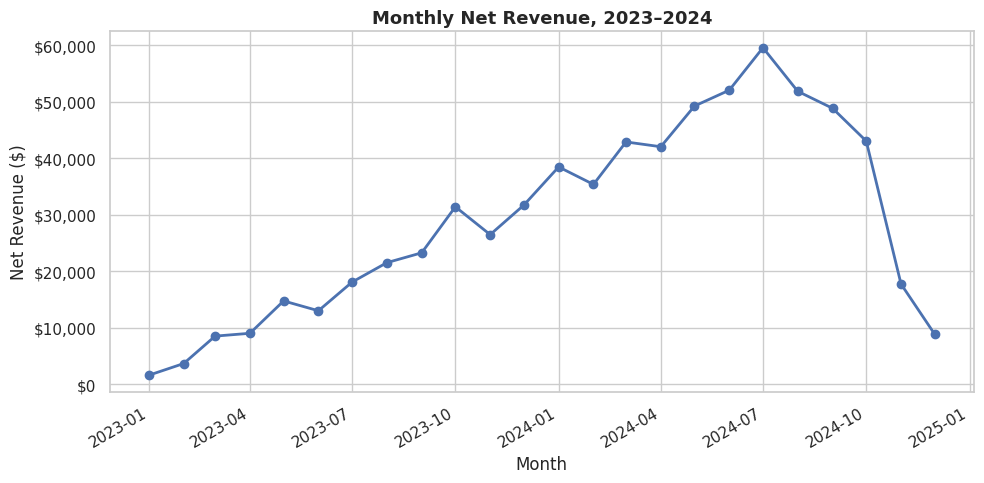

In [8]:
completed = clean[clean["OrderStatus"] == "Completed"].copy()

monthly = completed.groupby("OrderMonth")["NetRevenue"].sum().reset_index()

fig, ax = plt.subplots()
ax.plot(monthly["OrderMonth"], monthly["NetRevenue"], marker="o", linewidth=2)
ax.set_title("Monthly Net Revenue, 2023–2024")
ax.set_xlabel("Month")
ax.set_ylabel("Net Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


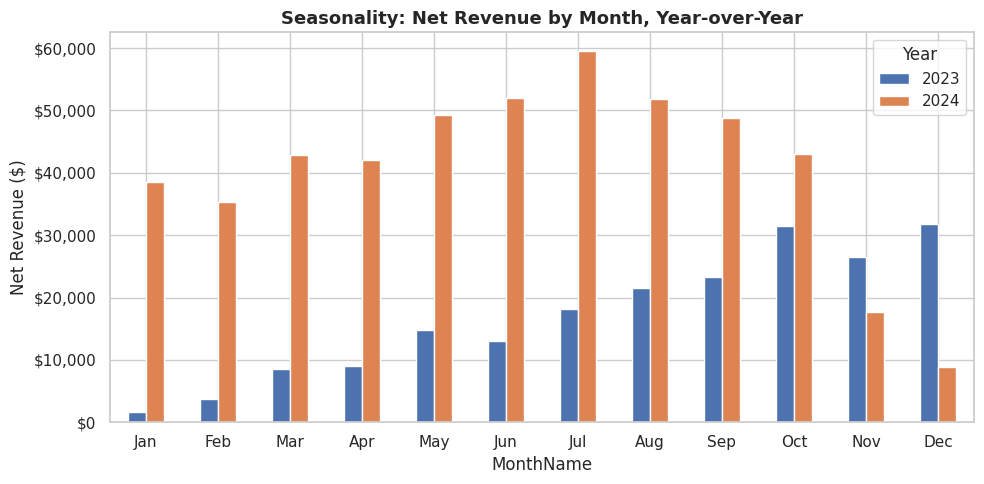

In [9]:
monthly["Year"] = monthly["OrderMonth"].dt.year
monthly["MonthName"] = monthly["OrderMonth"].dt.strftime("%b")

pivot = monthly.pivot(index="MonthName", columns="Year", values="NetRevenue")
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
pivot = pivot.reindex(month_order)

fig, ax = plt.subplots()
pivot.plot(kind="bar", ax=ax)
ax.set_title("Seasonality: Net Revenue by Month, Year-over-Year")
ax.set_ylabel("Net Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight:** revenue is meaningfully higher in November and December of both years, consistent with holiday shopping demand. Year-over-year, most months show growth, suggesting healthy underlying momentum rather than a one-off holiday spike.

## 4. Category & Regional Performance

In [10]:
cat_rev = completed.groupby("Category")["NetRevenue"].agg(["sum", "count"]).rename(
    columns={"sum": "NetRevenue", "count": "Orders"}
).sort_values("NetRevenue", ascending=False)
cat_rev["AvgOrderValue"] = (cat_rev["NetRevenue"] / cat_rev["Orders"]).round(2)
cat_rev


,NetRevenue,Orders,AvgOrderValue
Category,,,
Electronics,266939.087064,1488,179.39
Home & Kitchen,133990.260697,1078,124.30
Sports & Outdoors,122065.633940,866,140.95
Apparel,91739.434240,1206,76.07
Beauty,42019.129615,861,48.80
Office,36367.313926,627,58.00


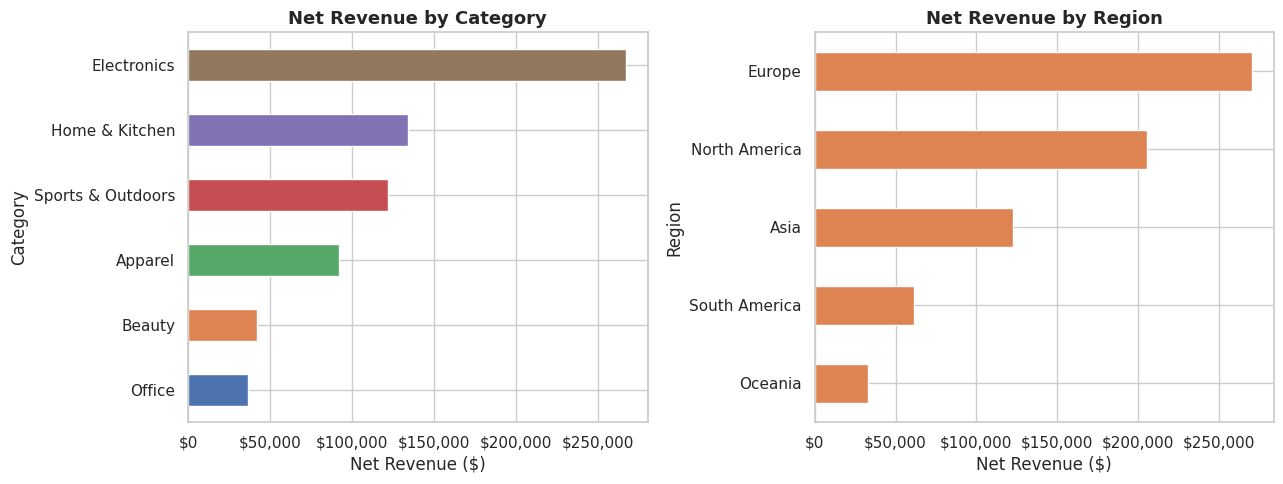

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cat_rev["NetRevenue"].sort_values().plot(kind="barh", ax=axes[0], color=sns.color_palette("deep"))
axes[0].set_title("Net Revenue by Category")
axes[0].set_xlabel("Net Revenue ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

region_rev = completed.groupby("Region")["NetRevenue"].sum().sort_values()
region_rev.plot(kind="barh", ax=axes[1], color=sns.color_palette("deep")[1])
axes[1].set_title("Net Revenue by Region")
axes[1].set_xlabel("Net Revenue ($)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()


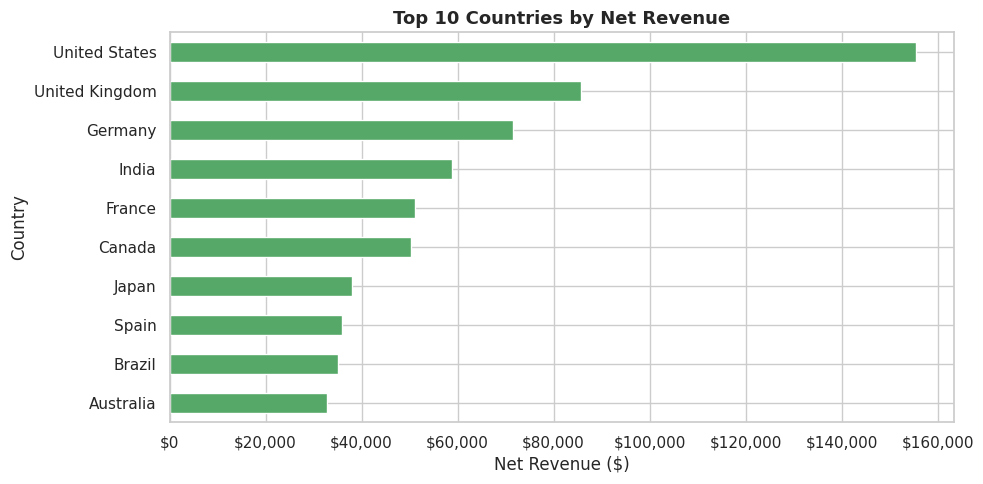

In [12]:
top_countries = completed.groupby("Country")["NetRevenue"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
top_countries.sort_values().plot(kind="barh", ax=ax, color=sns.color_palette("deep")[2])
ax.set_title("Top 10 Countries by Net Revenue")
ax.set_xlabel("Net Revenue ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()


**Insight:** Electronics and Apparel lead in total revenue, but check the `AvgOrderValue` column above — a category with fewer orders but a much higher average order value (Electronics/Sports & Outdoors) may be more efficient to market to than one that wins purely on volume. North America and Europe dominate regional revenue, with the U.S. as the single largest country market.

## 5. Where Are We Losing Orders? Returns & Cancellations

OrderStatus
Completed    87.5
Returned      8.4
Cancelled     4.1
Name: proportion, dtype: float64


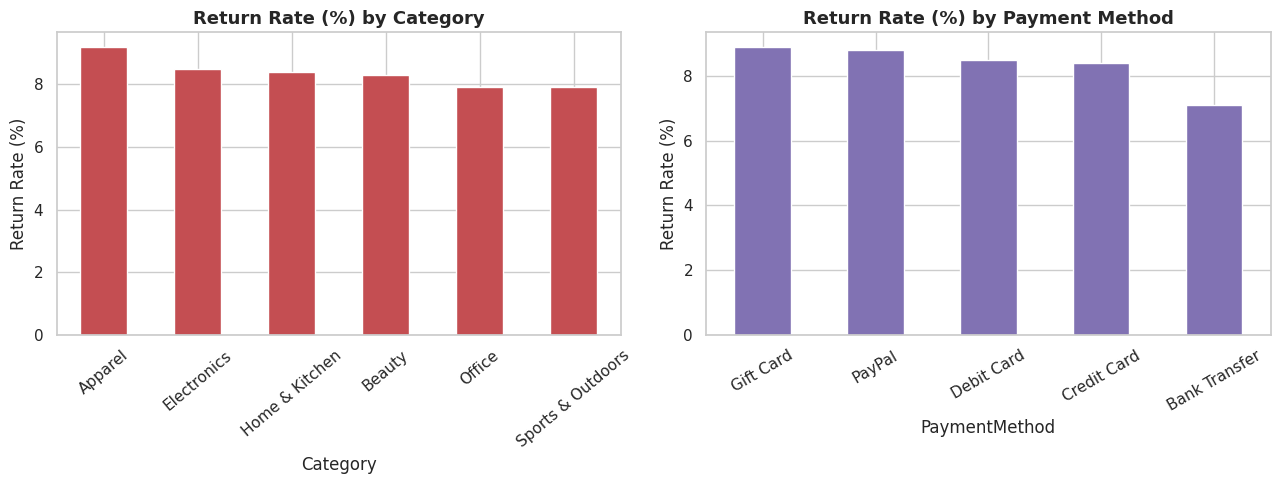

In [13]:
status_counts = clean["OrderStatus"].value_counts(normalize=True).mul(100).round(1)
print(status_counts)

return_by_cat = (
    clean.groupby("Category")["OrderStatus"]
    .apply(lambda s: (s == "Returned").mean() * 100)
    .sort_values(ascending=False)
    .round(1)
)
return_by_pay = (
    clean.groupby("PaymentMethod")["OrderStatus"]
    .apply(lambda s: (s == "Returned").mean() * 100)
    .sort_values(ascending=False)
    .round(1)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
return_by_cat.plot(kind="bar", ax=axes[0], color=sns.color_palette("deep")[3])
axes[0].set_title("Return Rate (%) by Category")
axes[0].set_ylabel("Return Rate (%)")
axes[0].tick_params(axis="x", rotation=40)

return_by_pay.plot(kind="bar", ax=axes[1], color=sns.color_palette("deep")[4])
axes[1].set_title("Return Rate (%) by Payment Method")
axes[1].set_ylabel("Return Rate (%)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


**Insight:** return rates hover close to the ~8% baseline across most categories and payment methods with only modest variation in this simulated dataset — in a real audit, any category sitting meaningfully above the average is worth a closer look (sizing issues, product quality, misleading listings).

## 6. Customer Segmentation (RFM Analysis)

RFM scores customers on **Recency** (days since last order), **Frequency** (number of orders), and **Monetary** value (total net revenue). This is one of the most actionable segmentation techniques for retention and marketing spend decisions.

In [14]:
snapshot_date = completed["OrderDate"].max() + pd.Timedelta(days=1)

rfm = completed.groupby("CustomerID").agg(
    Recency=("OrderDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("OrderID", "nunique"),
    Monetary=("NetRevenue", "sum")
).reset_index()

# Score 1 (worst) to 4 (best) per quartile
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

def segment_customer(score):
    if score >= 10:
        return "Champions"
    elif score >= 8:
        return "Loyal Customers"
    elif score >= 6:
        return "Potential Loyalists"
    elif score >= 4:
        return "At Risk"
    else:
        return "Lost / Low Value"

rfm["CustomerSegment"] = rfm["RFM_Score"].apply(segment_customer)
rfm.sort_values("Monetary", ascending=False).head(10)


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,CustomerSegment
173,CUST-00174,46,13,3420.637524,4,4,4,12,Champions
640,CUST-00641,54,16,2947.518500,4,4,4,12,Champions
465,CUST-00466,82,14,2901.458500,3,4,4,11,Champions
612,CUST-00613,105,14,2776.091000,2,4,4,10,Champions
222,CUST-00223,13,9,2709.865096,4,3,4,11,Champions
128,CUST-00129,47,14,2520.154582,4,4,4,12,Champions
486,CUST-00487,113,9,2326.717500,2,4,4,10,Champions
376,CUST-00377,68,14,2297.876500,3,4,4,11,Champions
303,CUST-00304,62,11,2212.548000,3,4,4,11,Champions
444,CUST-00445,110,9,2205.241000,2,4,4,10,Champions


In [15]:
seg_summary = rfm.groupby("CustomerSegment").agg(
    Customers=("CustomerID", "count"),
    AvgMonetary=("Monetary", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgRecencyDays=("Recency", "mean")
).round(1).sort_values("AvgMonetary", ascending=False)
seg_summary


,Customers,AvgMonetary,AvgFrequency,AvgRecencyDays
CustomerSegment,,,,
Champions,235,1276.5,10.1,59.7
Loyal Customers,195,901.5,8.0,85.9
Potential Loyalists,214,637.9,6.1,97.6
At Risk,133,461.9,4.8,137.2
Lost / Low Value,73,265.8,3.3,217.9


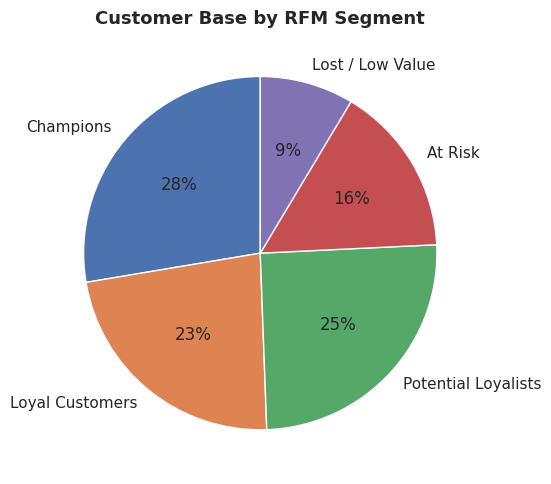

In [16]:
fig, ax = plt.subplots()
seg_order = seg_summary.index
counts = rfm["CustomerSegment"].value_counts().reindex(seg_order)
colors = sns.color_palette("deep", len(seg_order))
ax.pie(counts, labels=counts.index, autopct="%1.0f%%", colors=colors, startangle=90)
ax.set_title("Customer Base by RFM Segment")
plt.tight_layout()
plt.show()


**Insight:** "Champions" are a small share of the customer base but carry disproportionate revenue — the classic 80/20 pattern. "At Risk" and "Lost / Low Value" customers represent win-back opportunity: they've bought before (so acquisition cost is sunk) but haven't ordered recently.

## 7. Key Insights & Recommendations

**1. Seasonality is real and predictable.** Revenue consistently peaks in November–December. → Plan inventory, staffing, and marketing spend around this window well in advance; consider a Q1 promotion to smooth the post-holiday dip.

**2. Revenue is concentrated in a few categories and regions.** Electronics and Apparel, and North America/Europe, drive the majority of net revenue. → Protect these core lines with reliable stock, but treat smaller categories/regions as growth experiments with dedicated (smaller) budgets rather than starving them entirely.

**3. Returns are broadly stable but should be monitored continuously.** No single category or payment method stood out sharply in this dataset, but return-rate-by-category is a metric worth tracking monthly — small increases are often the earliest signal of a product quality or listing-accuracy problem.

**4. A small "Champions" segment likely drives outsized revenue.** → Build a loyalty/VIP program for this group (early access, free shipping thresholds) — retaining them is cheaper than acquiring new customers of equivalent value.

**5. "At Risk" and "Lost" customers are a low-hanging-fruit win-back opportunity.** → A targeted re-engagement email campaign (e.g., a time-limited discount) to these segments is typically far more cost-effective than pure top-of-funnel acquisition spend.

---
### Suggested next steps for a deeper dive
- Build a cohort retention curve (% of customers still active N months after first order).
- Bring in marketing spend by channel to compute true customer acquisition cost (CAC) and CAC-to-LTV ratio by segment.
- A/B test a win-back email against the "At Risk" segment and measure lift.
